In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

# Exercício

1. Gere uma amostra de tamanho $M$ de uma exponencial através do método de inversão visto em sala. Compare com uma exponencial gerada pelo numpy via histogramas. Comparem também com a densidade real da exponencial $f(x) = \lambda e^{-\lambda x}$ (isto é, seu histograma normalizado tem que ficar igual essa curva).

In [2]:
lbd = 10
M = 1000
U = np.random.uniform()
exp = (-1)*np.log(U)/lbd
print(exp)

0.25807902675583494


Aqui eu apenas utilizei o método da inversão para gerar uma exponencial

(array([507., 253., 123.,  58.,  34.,   9.,   6.,   3.,   4.,   3.]),
 array([2.08213348e-05, 7.55538663e-02, 1.51086911e-01, 2.26619956e-01,
        3.02153001e-01, 3.77686046e-01, 4.53219091e-01, 5.28752136e-01,
        6.04285181e-01, 6.79818226e-01, 7.55351271e-01]),
 <BarContainer object of 10 artists>)

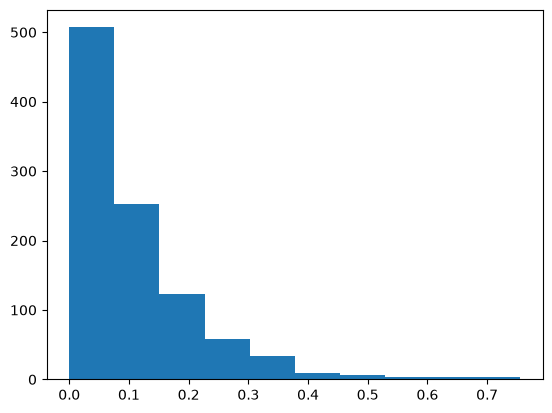

In [3]:
U = np.random.uniform(size=M)
exp = (-1)*np.log(U)/lbd

plt.hist(exp)
    

Aqui eu gerei uma amostra de exponenciais e fiz um histograma

(array([488., 256., 122.,  57.,  41.,  17.,  10.,   6.,   1.,   2.]),
 array([2.65804803e-05, 6.77748743e-02, 1.35523168e-01, 2.03271462e-01,
        2.71019756e-01, 3.38768050e-01, 4.06516343e-01, 4.74264637e-01,
        5.42012931e-01, 6.09761225e-01, 6.77509519e-01]),
 <BarContainer object of 10 artists>)

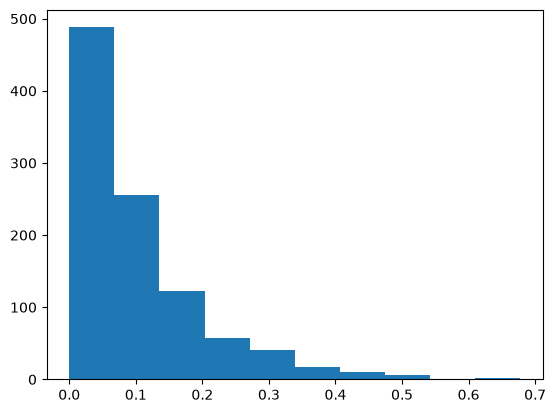

In [4]:
numpy = np.random.exponential(1/lbd, size=M)
plt.hist(numpy)

Aqui eu usei a própria função do python para gerar uma amostra exponencial, mas a parametrização dela considera a média como 1/lbd

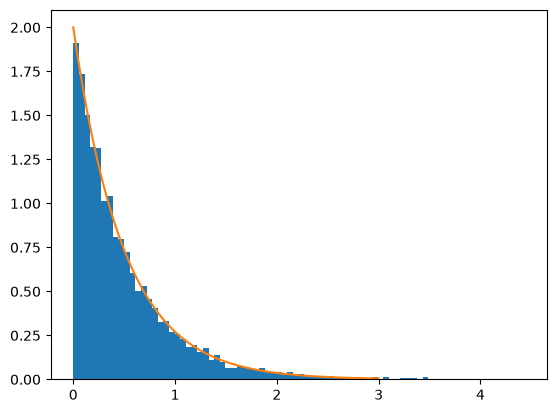

In [5]:
lamb = 2
x = np.linspace(0,3,10_000)
y = lamb*np.exp(-lamb*x)

amostra = np.random.exponential(1/lamb, size=10_000)

plt.hist(amostra, density=True, bins=80)
plt.plot(x,y)

Aqui eu só comparei o gráfico gerado pelas amostras de de exponenciais com a função de distribuição da exponencial

2. Agora considere $T_n = X_n / n$ onde $X_n$ é uma Geométrica com parâmetro $\lambda/n$. Mostre que quando $n$ é grande, isso se aproxima de uma exponencial.

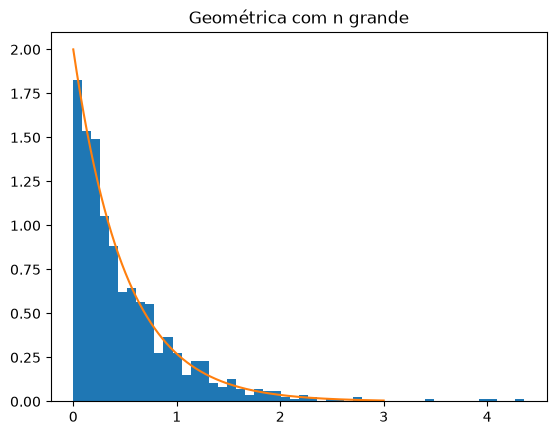

In [6]:
n = 10000
u = np.random.uniform(size=M)
Xn = np.ceil(np.log(u)/np.log(1-(lamb/n)))
Tn = Xn/n
plt.hist(Tn, density=True, bins=50)
plt.plot(x,y)
plt.title('Geométrica com n grande')
plt.show()

3. Considere agora $X_1, X_2, \ldots$ variáveis aleatórias i.i.d. com distribuição Exponencial de parâmetro $\lambda$. Vá somando essas variáveis até que a soma ultrapasse $1$ e conte quantas delas foram somadas antes de ultrapassar $1$. Repita esse procedimento $M$ vezes e mostre empiricamente que essa quantidade segue aproximadamente uma Poisson de parâmetro $\lambda$. Compare o histograma obtido com uma Poisson gerada pelo numpy e com a função de probabilidade real da Poisson.